In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv('house_price_dataset.csv')
df.head(10)


,area,bedrooms,bathrooms,stories,parking,age,distance_city,location_score,furnished,price
0,3419,1,1,3,1,8,4.5,4,0,119.0
1,930,1,1,2,1,17,12.8,8,0,61.3
2,3032,4,4,4,2,1,15.7,5,1,131.1
3,1436,2,2,1,0,13,3.7,10,1,97.3
4,977,4,3,4,0,18,7.3,9,1,89.5
5,1084,1,1,3,0,8,17.6,7,1,63.0
6,2294,2,2,3,1,22,6.8,9,0,107.0
7,1500,5,5,2,3,13,6.9,9,0,114.1
8,1029,2,1,3,3,9,3.2,8,1,82.2
9,2844,4,5,2,2,5,6.4,8,1,149.4


In [3]:
# EDA
df.shape

(100, 10)

In [4]:
df.columns

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'age',
       'distance_city', 'location_score', 'furnished', 'price'],
      dtype='str')

In [5]:
df.isna().sum()

area              0
bedrooms          0
bathrooms         0
stories           0
parking           0
age               0
distance_city     0
location_score    0
furnished         0
price             0
dtype: int64

In [6]:
df.corr()

,area,bedrooms,bathrooms,stories,parking,age,distance_city,location_score,furnished,price
area,1.000000,0.068013,0.131468,-0.022267,-0.092974,-0.007828,0.035115,-0.099391,0.002525,0.802726
bedrooms,0.068013,1.000000,0.872833,0.034357,0.089622,-0.031281,-0.034633,0.072534,-0.087327,0.415098
bathrooms,0.131468,0.872833,1.000000,0.068073,0.044153,-0.076913,-0.019397,0.129800,-0.086672,0.488961
stories,-0.022267,0.034357,0.068073,1.000000,-0.020985,-0.159747,0.048746,0.071670,0.140741,0.135983
parking,-0.092974,0.089622,0.044153,-0.020985,1.000000,-0.035964,0.059706,0.042720,0.114761,0.045573
age,-0.007828,-0.031281,-0.076913,-0.159747,-0.035964,1.000000,0.016381,0.027295,-0.065602,-0.176598
distance_city,0.035115,-0.034633,-0.019397,0.048746,0.059706,0.016381,1.000000,0.081746,0.162860,-0.092144
location_score,-0.099391,0.072534,0.129800,0.071670,0.042720,0.027295,0.081746,1.000000,-0.044047,0.277600
furnished,0.002525,-0.087327,-0.086672,0.140741,0.114761,-0.065602,0.162860,-0.044047,1.000000,0.075505
price,0.802726,0.415098,0.488961,0.135983,0.045573,-0.176598,-0.092144,0.277600,0.075505,1.000000


<Axes: >

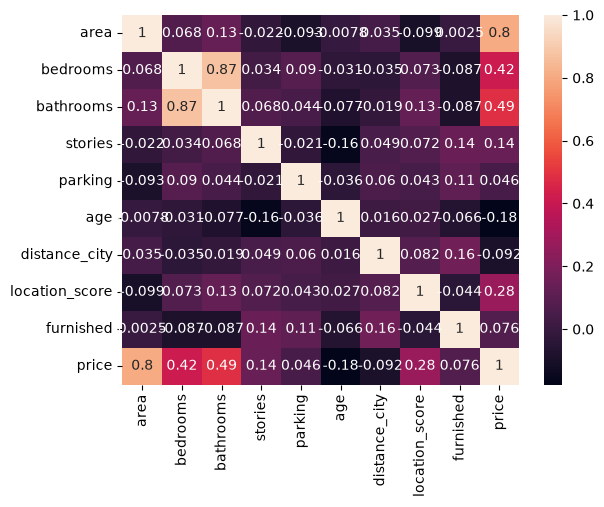

In [7]:
# with the help of heatmap we can describe the co-relation
sns.heatmap(df.corr(), annot=True)

<Axes: >

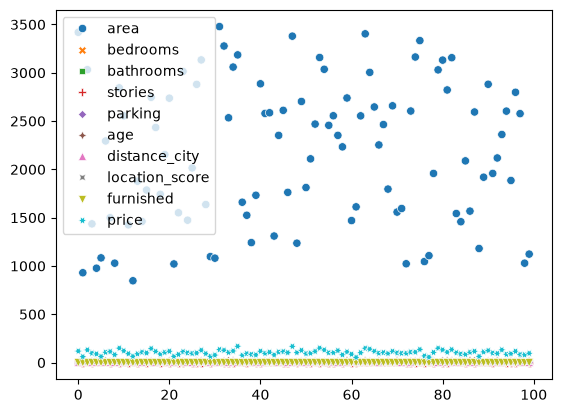

In [8]:
# numerical data scatter
sns.scatterplot(data=df)

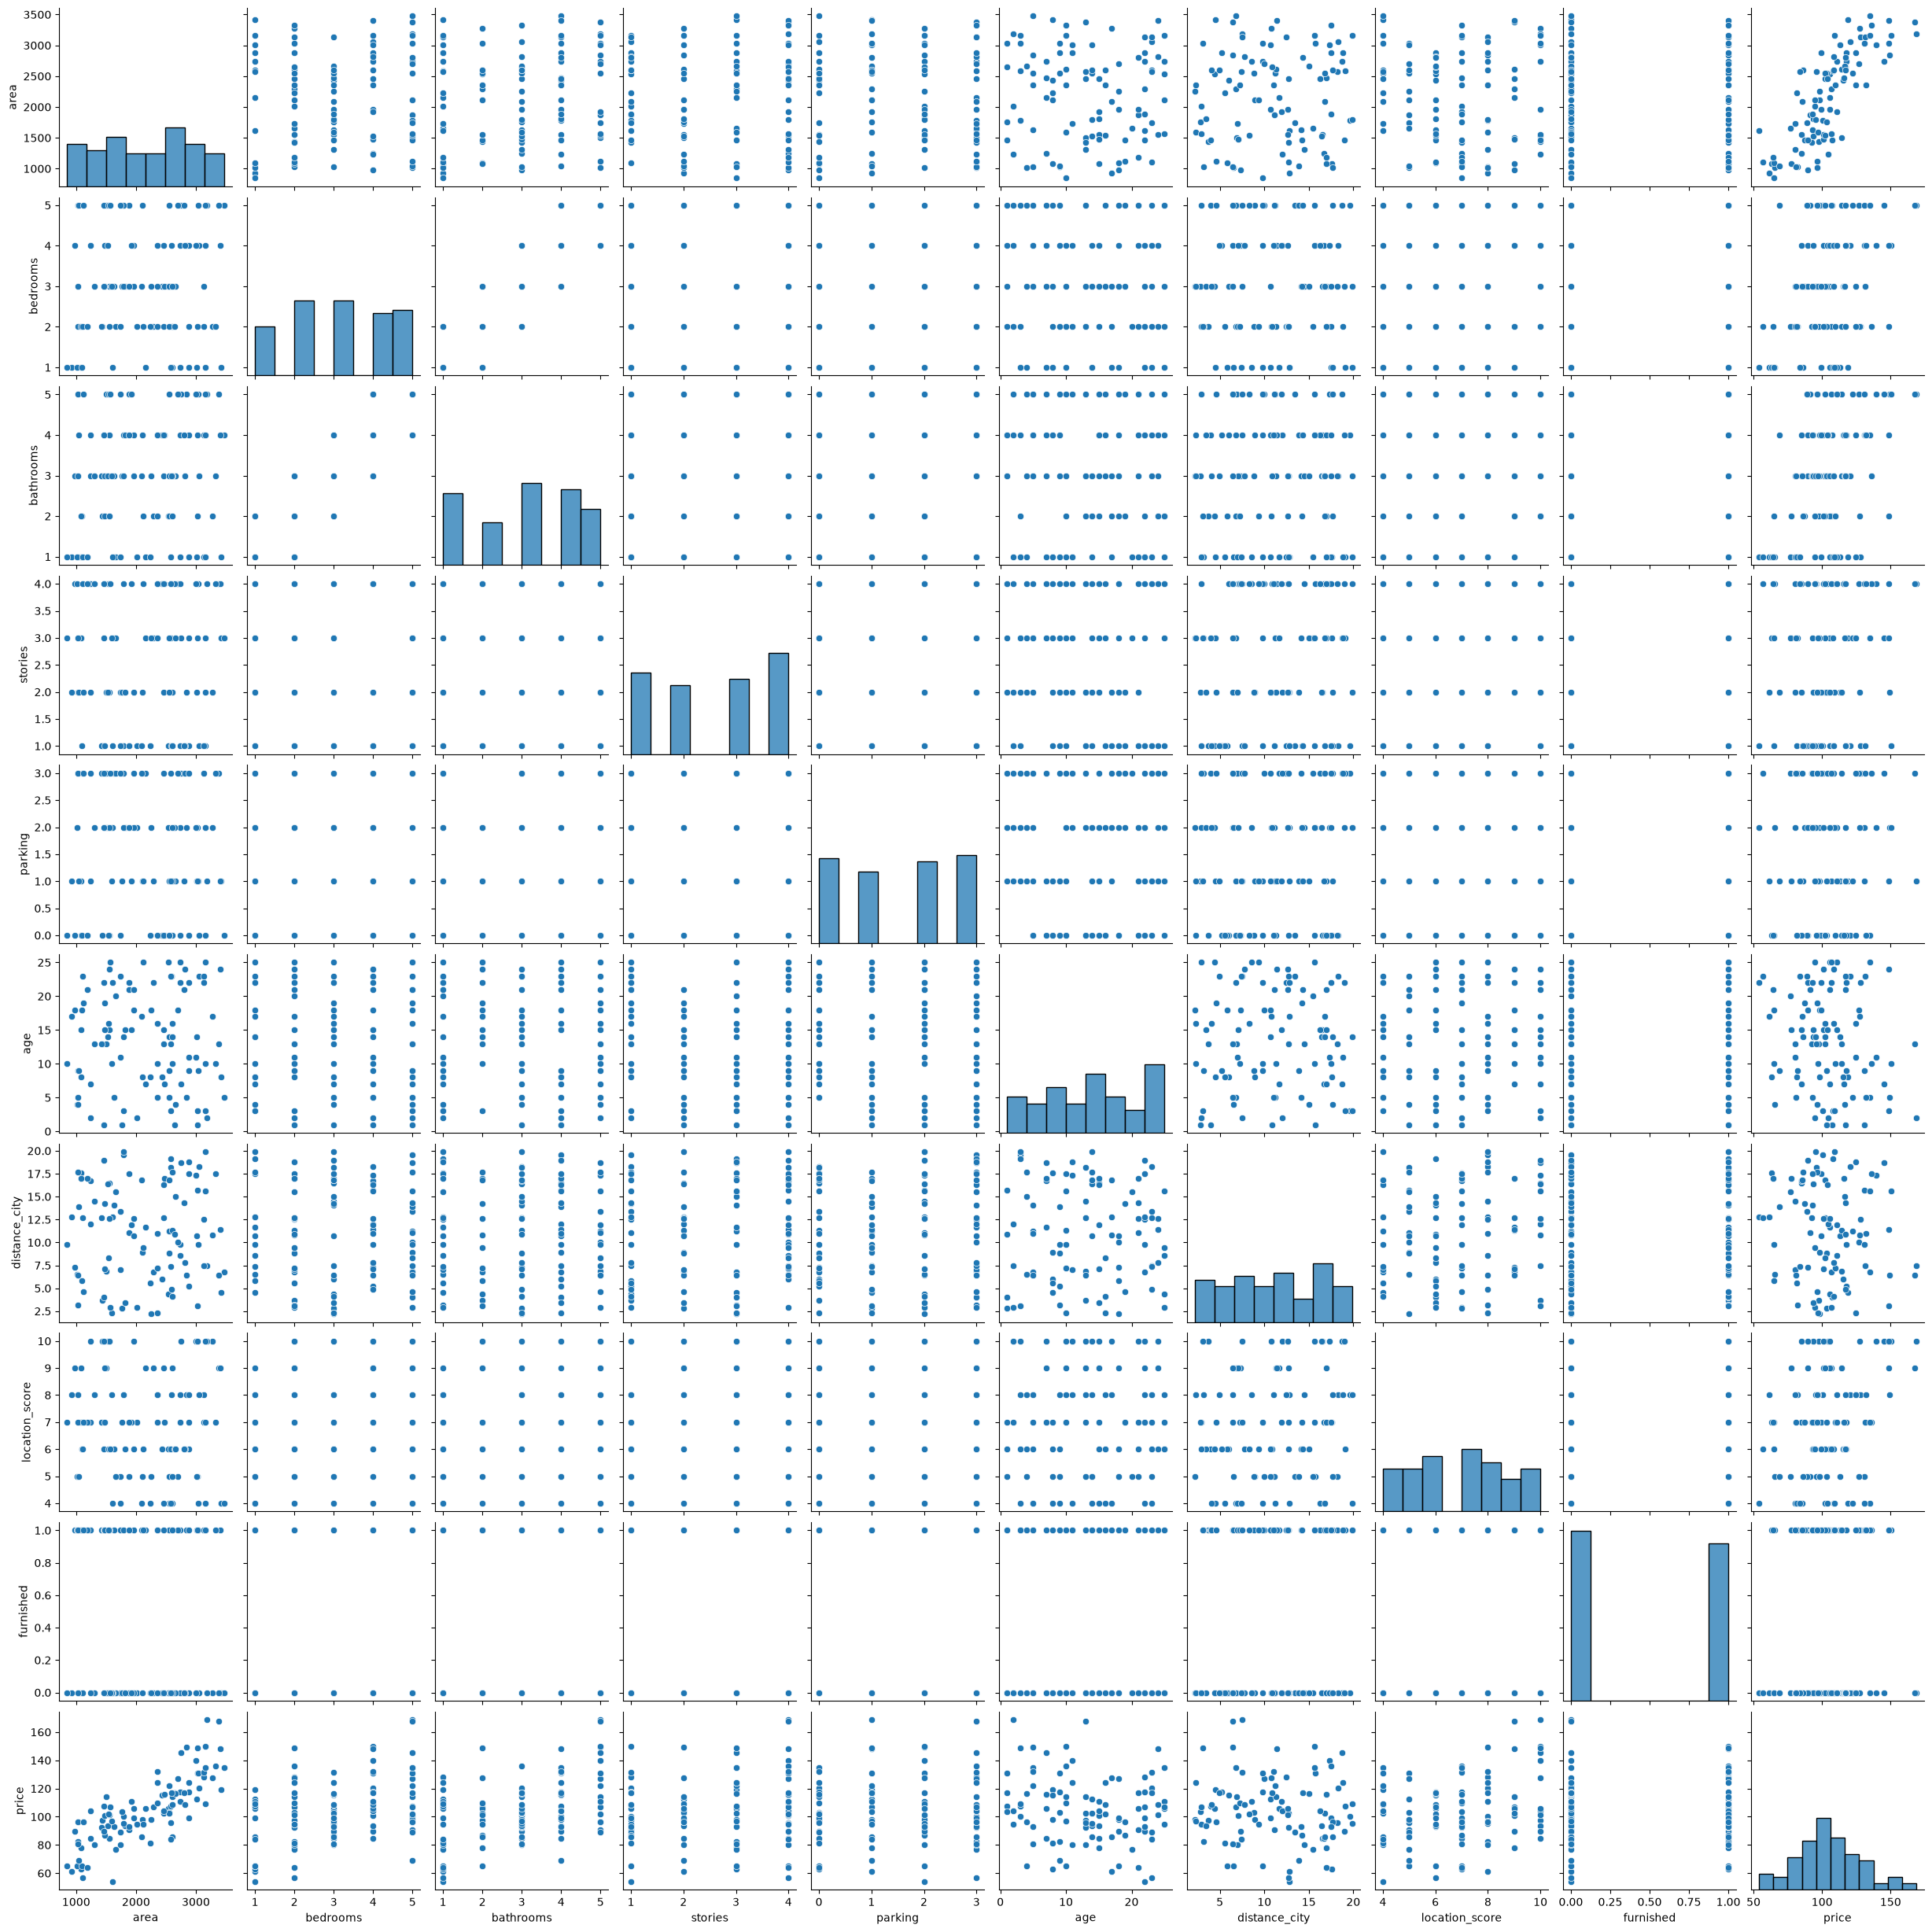

In [9]:
#pairplot
sns.pairplot(data=df)

In [10]:
# data are divided into two parts
X = df.iloc[:, :9]
y = df.iloc[:, -1]

In [11]:
print(X.shape)
print(y.shape)

(100, 9)
(100,)


In [12]:
from sklearn.model_selection import train_test_split


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(80, 9)
(20, 9)
(80,)
(20,)


In [15]:
# model build
model = LinearRegression()
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[ 0.03, 2.54, 3.45,...,-0.73, 4.33, 5.76]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['area','bedrooms','bathrooms',...,'distance_city','location_score', 'furnished']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.658
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(9)


In [17]:
y_pred = model.predict(X_test)
y_pred

array([ 99.9867925 , 152.60208488,  96.08036077, 123.69806809,
       110.75492906,  79.58499028,  94.79870189, 134.61515741,
       114.54531276, 116.56937131,  83.92273032,  77.20050708,
       108.58086261, 102.0327857 , 119.5091352 ,  88.72161764,
        71.1844361 ,  59.73770244,  56.67588877, 136.73768268])

In [18]:
score = model.score(X_test, y_test)

print("Model R² Score:", score)
print("Model Accuracy:", round(score * 100, 2), "%")

Model R² Score: 0.9618772023152126
Model Accuracy: 96.19 %
